# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load data
df = pd.read_csv("data.csv")
pd.set_option('display.max_columns', None)
df.head(20)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,380,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,50,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
df.duplicated().sum()

12

In [9]:
df.drop_duplicates()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [10]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Customer Demographics Analysis

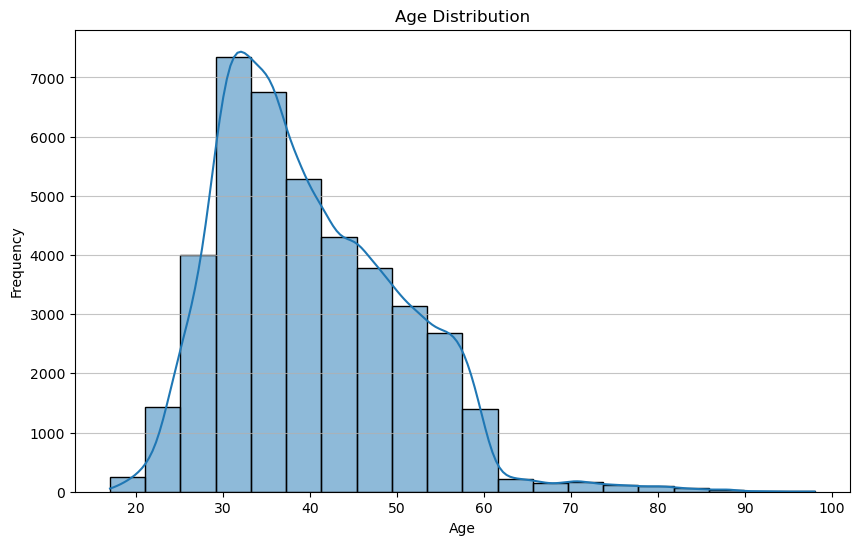

In [12]:
# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

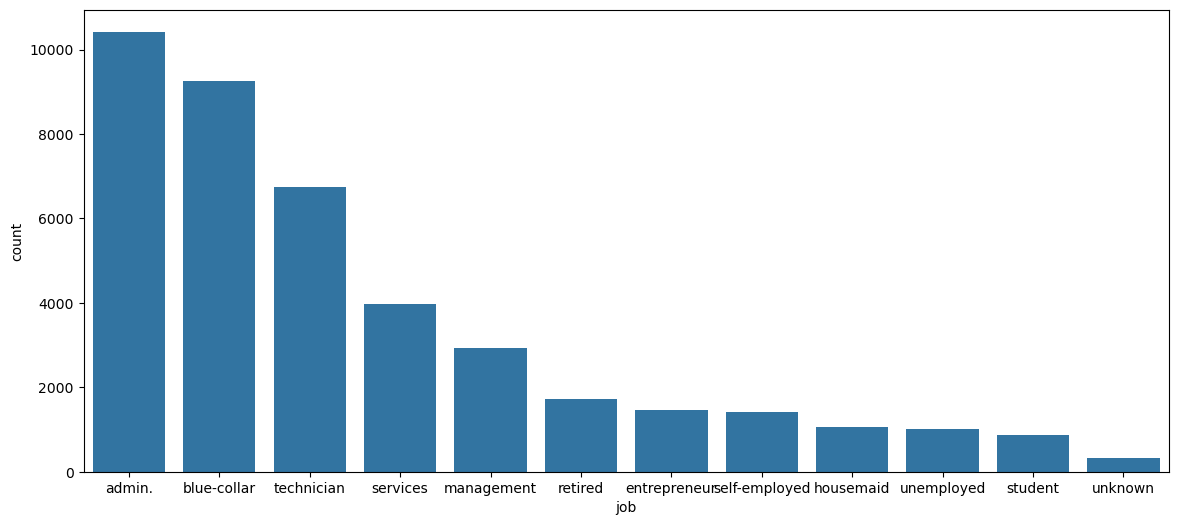

In [13]:
# Job distribution
plt.figure(figsize=(14,6))
sns.countplot(x='job', data=df, order=df['job'].value_counts().index)
plt.show()

## Balance & Deposit Trends

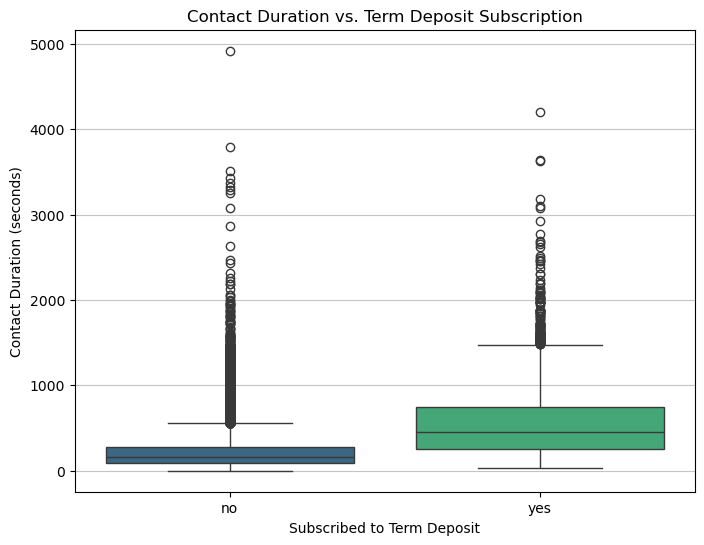

In [15]:
# Average balance by deposit subscription
# We don't have balance column so we use duration istead for calculation.

plt.figure(figsize=(8, 6))
sns.boxplot(x='y', y='duration', data=df, palette='viridis', hue='y', legend=False)
plt.title('Contact Duration vs. Term Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Contact Duration (seconds)')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Contact Duration and Term Deposit Subscription

This plot visualizes the distribution of 'duration' (last contact duration in seconds) for customers who subscribed to a term deposit ('yes') and those who did not ('no'). A longer contact duration is generally associated with a higher likelihood of subscription.

## Campaign Effectiveness

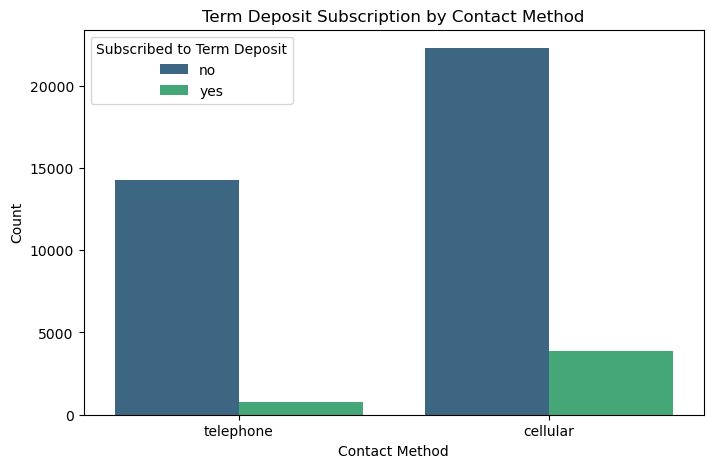

In [18]:
# Contact method analysis
plt.figure(figsize=(8, 5))
sns.countplot(x='contact', hue='y', data=df, palette='viridis')
plt.title('Term Deposit Subscription by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Count')
plt.legend(title='Subscribed to Term Deposit')
plt.show()

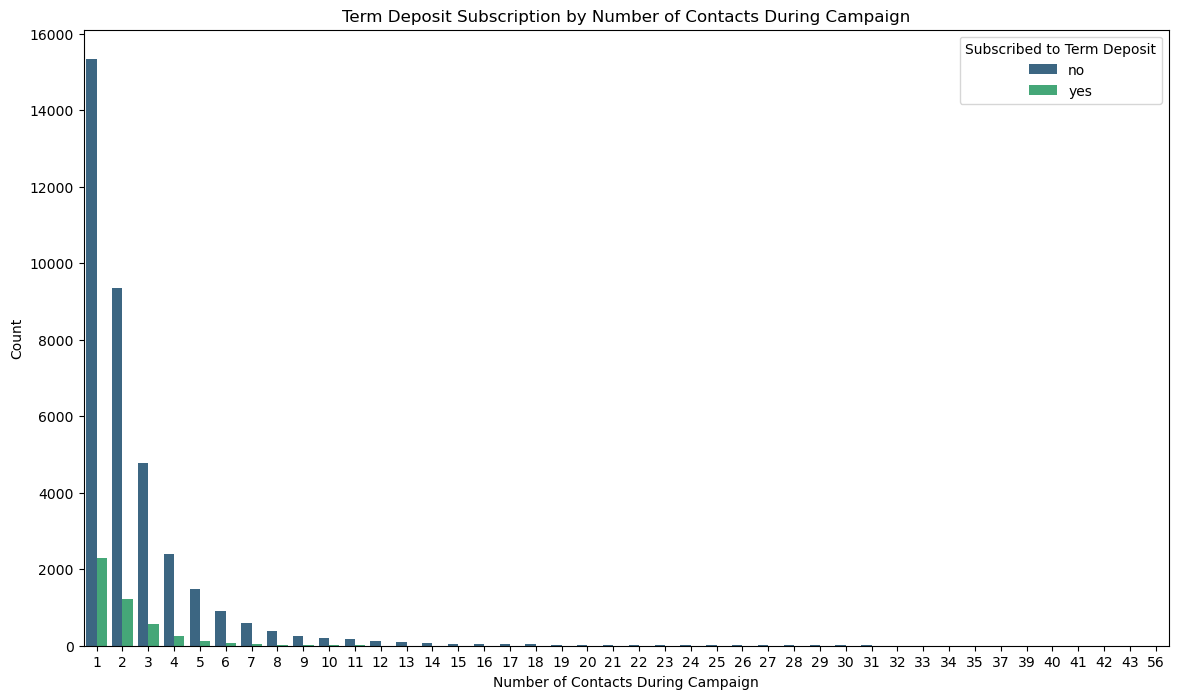

In [19]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(14, 8))
sns.countplot(x='campaign', hue='y', data=df, palette='viridis')
plt.title('Term Deposit Subscription by Number of Contacts During Campaign')
plt.xlabel('Number of Contacts During Campaign')
plt.ylabel('Count')
plt.legend(title='Subscribed to Term Deposit')
plt.show()

## Correlation Heatmap

In [21]:
# Correlation of numerical variables
corr = df.corr(numeric_only=True)
corr

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


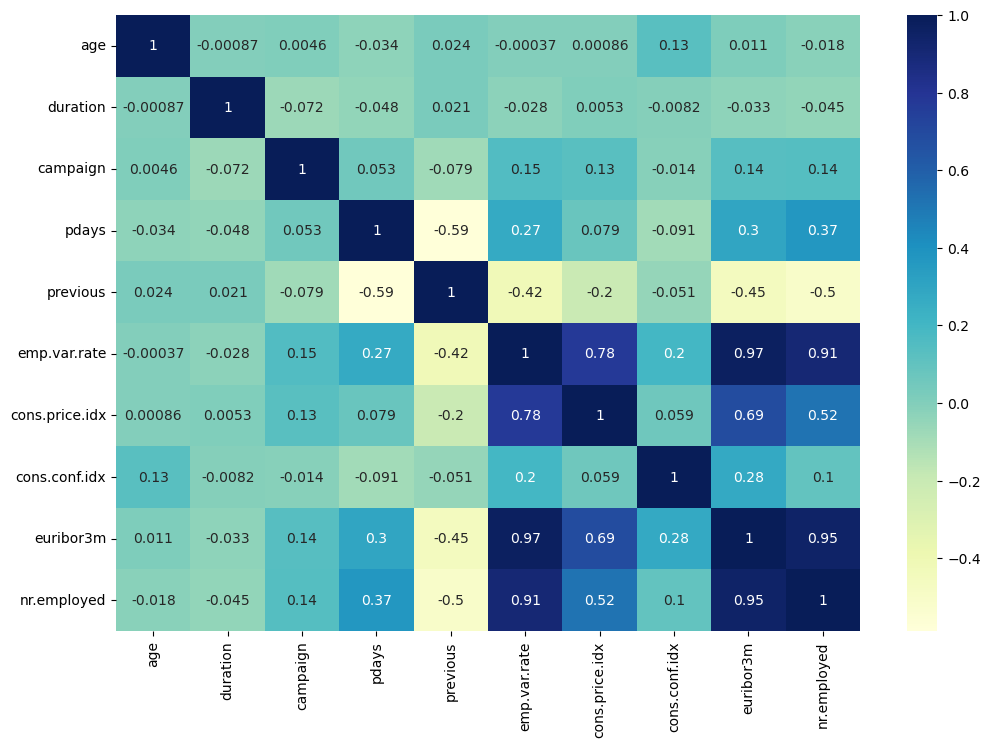

In [22]:
plt.figure(figsize= (12,8))
sns.heatmap(corr, annot = True, cmap="YlGnBu")
plt.show()

In [23]:
# categorucal columns
df_cat = df.select_dtypes(include=object).columns
df_cat
for clm in df_cat:
  print(f"total unique values in '{clm}' is {df[clm].nunique()}")
  print(f"values in '{clm}' are {df[clm].unique()}")
  print("-"*60)

total unique values in 'job' is 12
values in 'job' are ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
------------------------------------------------------------
total unique values in 'marital' is 4
values in 'marital' are ['married' 'single' 'divorced' 'unknown']
------------------------------------------------------------
total unique values in 'education' is 8
values in 'education' are ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
------------------------------------------------------------
total unique values in 'default' is 3
values in 'default' are ['no' 'unknown' 'yes']
------------------------------------------------------------
total unique values in 'housing' is 3
values in 'housing' are ['no' 'yes' 'unknown']
------------------------------------------------------------
total unique values in 'loan' is 3


## Predictive Modeling (Logistic Regression)

In [ ]:


# Separate features (X) and target (y)
X = df.drop('y', axis=1)
y = df['y']

# Convert 'yes'/'no' to 1/0 for the target variable
y = y.map({'yes': 1, 'no': 0})

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_test.info()
X_test.dropna(inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 8238 entries, 32884 to 1871
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             8238 non-null   int64  
 1   job             8238 non-null   object 
 2   marital         8238 non-null   object 
 3   education       8238 non-null   object 
 4   default         8238 non-null   object 
 5   housing         8238 non-null   object 
 6   loan            8238 non-null   object 
 7   contact         8238 non-null   object 
 8   month           8238 non-null   object 
 9   day_of_week     8238 non-null   object 
 10  duration        8238 non-null   int64  
 11  campaign        8238 non-null   int64  
 12  pdays           8238 non-null   int64  
 13  previous        8238 non-null   int64  
 14  poutcome        8238 non-null   object 
 15  emp.var.rate    8238 non-null   float64
 16  cons.price.idx  8238 non-null   float64
 17  cons.conf.idx   8238 non-null   fl

In [27]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8238 entries, 32884 to 1871
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             8238 non-null   int64  
 1   job             8238 non-null   object 
 2   marital         8238 non-null   object 
 3   education       8238 non-null   object 
 4   default         8238 non-null   object 
 5   housing         8238 non-null   object 
 6   loan            8238 non-null   object 
 7   contact         8238 non-null   object 
 8   month           8238 non-null   object 
 9   day_of_week     8238 non-null   object 
 10  duration        8238 non-null   int64  
 11  campaign        8238 non-null   int64  
 12  pdays           8238 non-null   int64  
 13  previous        8238 non-null   int64  
 14  poutcome        8238 non-null   object 
 15  emp.var.rate    8238 non-null   float64
 16  cons.price.idx  8238 non-null   float64
 17  cons.conf.idx   8238 non-null   fl

In [28]:
y_test.info()
y_test.dropna(inplace=True)

<class 'pandas.core.series.Series'>
Index: 8238 entries, 32884 to 1871
Series name: y
Non-Null Count  Dtype
--------------  -----
8238 non-null   int64
dtypes: int64(1)
memory usage: 128.7 KB


### Feature Encoding Pipeline

We'll create a preprocessing pipeline using `ColumnTransformer` to handle different types of features:
- **Numerical features**: These will be scaled using `StandardScaler`.
- **Categorical features**: These will be transformed using `OneHotEncoder` to convert them into a numerical format suitable for machine learning models. Since all identified categorical features have relatively low cardinality, One-Hot Encoding is an appropriate choice.

In [30]:
# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

### Model Training

Now, we'll combine the preprocessing steps with a `LogisticRegression` model into a single pipeline. This ensures that the preprocessing is applied consistently to both training and testing data, preventing data leakage.

In [32]:
# Create the full pipeline with preprocessor and Logistic Regression model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [33]:
# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9114

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.43      0.52       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



In [ ]:
from imblearn.over_sampling import SMOTENC

In [41]:
cat_indices = [X_train.columns.get_loc(col) for col in categorical_cols]
smotenc = SMOTENC(categorical_features = cat_indices, random_state = 42)
X_train_reshampled, y_train_resampled = smotenc.fit_resample(X_train, y_train)

In [43]:
model_pipeline.fit(X_train_reshampled, y_train_resampled)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(random_state=42, solver='liblinear'))])

In [45]:
# Make predictions on the test set
new_y_pred = model_pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, new_y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, new_y_pred))

Accuracy: 0.8744

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      7303
           1       0.47      0.79      0.59       935

    accuracy                           0.87      8238
   macro avg       0.72      0.84      0.76      8238
weighted avg       0.91      0.87      0.89      8238



### Feature Importance from Logistic Regression

To understand which features are most influential in predicting term deposit subscription, we can examine the coefficients of the trained Logistic Regression model. Features with larger absolute coefficient values have a stronger impact on the prediction. Positive coefficients indicate a positive correlation with subscription (higher value means higher likelihood of 'yes'), while negative coefficients indicate a negative correlation.

In [47]:
# Extract the logistic regression model from the pipeline
logistic_model = model_pipeline.named_steps['classifier']

# Get feature names from the preprocessor
numerical_features = numerical_cols.tolist()

# For one-hot encoded categorical features, we need to get the new column names
onehot_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
categorical_feature_names = onehot_encoder.get_feature_names_out(categorical_cols)

# Combine all feature names
feature_names = numerical_features + categorical_feature_names.tolist()

coefficients = logistic_model.coef_[0]

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient value to see the most impactful features
feature_importance_df['Absolute_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Absolute_Coefficient', ascending=False)

display(feature_importance_df.head(10))

,Feature,Coefficient,Absolute_Coefficient
5,emp.var.rate,-2.738923,2.738923
1,duration,2.553979,2.553979
8,euribor3m,2.144473,2.144473
41,loan_unknown,-1.704497,1.704497
50,month_mar,1.493463,1.493463
60,poutcome_failure,-1.322155,1.322155
25,marital_unknown,-1.246377,1.246377
9,nr.employed,-1.185998,1.185998
40,loan_no,1.164304,1.164304
35,default_unknown,-1.080539,1.080539


C:\Users\saklani\AppData\Local\Temp\ipykernel_13508\1927187533.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df.head(10), palette='coolwarm')


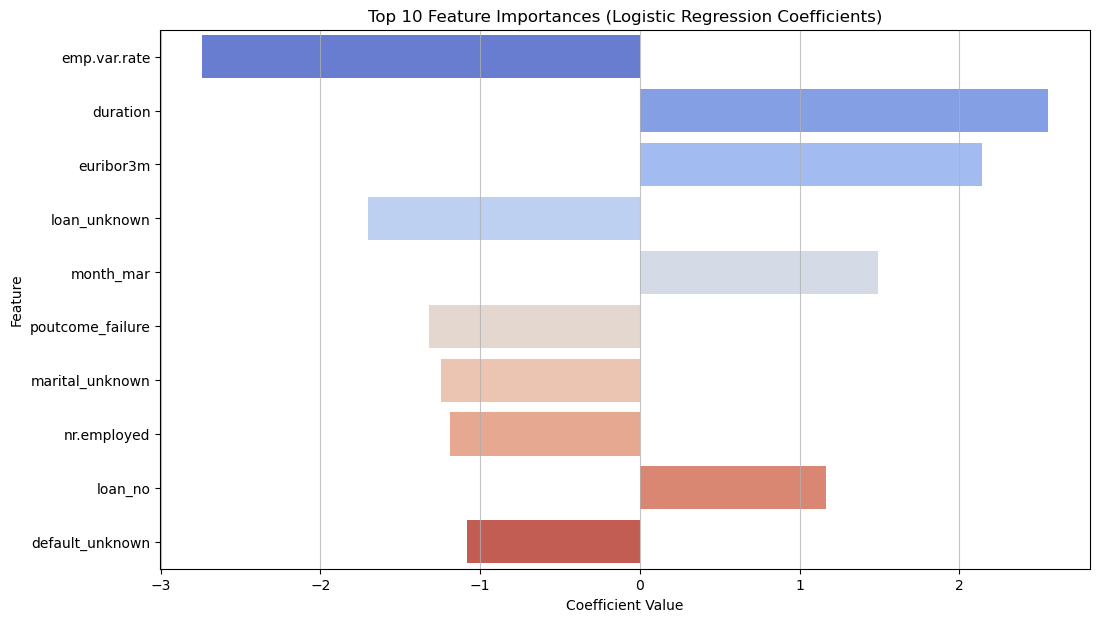

In [49]:
# Visualize the top 10 most important features


plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_df.head(10), palette='coolwarm')
plt.title('Top 10 Feature Importances (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.75)
plt.show()

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.